<a href="https://colab.research.google.com/github/Wandersonelias/notebooks/blob/master/Pratica_01_UC3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação e Exploração dos Dados

In [ ]:
#importando as bibliotecas necessarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [ ]:
session = requests.session()

In [ ]:
#Função para carregar aquivos csv armazenados em meu respositorio no Github
def carregar_dados(url,file_name):
  response = session.get(url)
  if response.status_code == 200:
    print("Prosseguir com a operação de Download dos arquivos!")
    with open(f"{file_name}.csv",'wb') as file:
          file.write(response.content)
          print("Finalizado Download!")
  else:
      print("Error")
      print(response.raise_for_status)
  dataframe = pd.read_csv(f"{file_name}.csv")
  return dataframe

In [ ]:
#Carregar e analisar a primeiras linhas do Dataset
df = carregar_dados("https://raw.githubusercontent.com/Wandersonelias/Datasets/refs/heads/master/flights_delays_120.csv","flights_delays_120")
df.head()

Prosseguir com a operação de Download dos arquivos!
Finalizado Download!


,airline,origin,destination,departure_hour,day_of_week,weather,delayed
0,TravelAir,GIG,FOR,11,5,Storm,0
1,JetCloud,CNF,SSA,11,3,Wind,0
2,SkyWings,POA,SSA,4,5,Fog,1
3,JetCloud,BSB,FOR,6,4,Storm,1
4,JetCloud,GRU,FOR,3,1,Rain,1


In [ ]:
#Analisando a forma do Dataframe
df.shape

(120, 7)

In [ ]:
# Analisando os nomes das colunas Dataframe
df.columns


Index(['airline', 'origin', 'destination', 'departure_hour', 'day_of_week',
       'weather', 'delayed'],
      dtype='object')

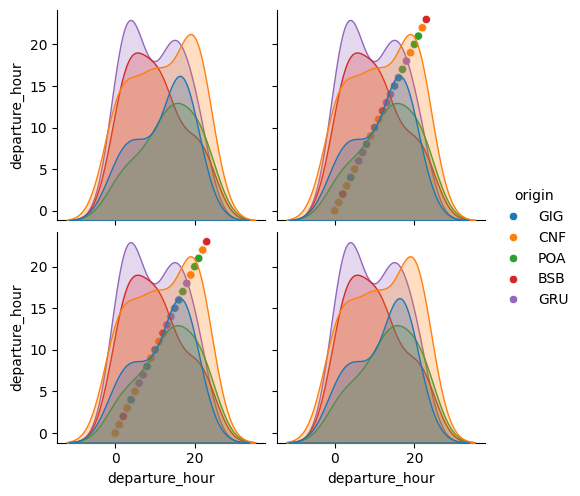

In [ ]:
sns.pairplot(df,vars=['departure_hour','departure_hour'],hue='origin')


In [ ]:
# Analisando as informações iniciais do Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   airline         120 non-null    object
 1   origin          120 non-null    object
 2   destination     120 non-null    object
 3   departure_hour  120 non-null    int64 
 4   day_of_week     120 non-null    int64 
 5   weather         120 non-null    object
 6   delayed         120 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 6.7+ KB


In [ ]:
#Sem valores nulos ou ausentes
df.isnull().sum()

,0
airline,0
origin,0
destination,0
departure_hour,0
day_of_week,0
weather,0
delayed,0


# Preparação do Dados

In [ ]:
# Separando as features X, do nosso target que nesse caso é dealayd

#Salvando features em X
X = df.drop("delayed",axis=1)

#Salvando o target em y
y = df["delayed"]

#Convertendo categorias usando o One-Hot-Enconding, com essa tecnica cada variavel de categorias passa a ter uma coluna especifica com o valor True ou False
X = pd.get_dummies(X)

#Dividindo os dados para treinamento nas proporções de 70% para treinamento e 30% para testes
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)


In [ ]:
X

,departure_hour,day_of_week,airline_AirOne,airline_FlyFast,airline_JetCloud,airline_SkyWings,airline_TravelAir,origin_BSB,origin_CNF,origin_GIG,...,destination_BEL,destination_CWB,destination_FOR,destination_REC,destination_SSA,weather_Clear,weather_Fog,weather_Rain,weather_Storm,weather_Wind
0,11,5,False,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,False
1,11,3,False,False,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,4,5,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
3,6,4,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,3,1,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,8,5,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
116,6,4,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
117,3,4,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
118,20,6,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
#conferindo a proporção dos dados treino e de teste
print(f"Dados de treino: {X_train.shape} Dados de teste: {y_test.shape}")

Dados de treino: (84, 22) Dados de teste: (36,)


# Treinamento do modelo XGBoost

In [ ]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

#Instanciando o modelo do XGBoost com o nossos dados preparados anteriormente
model = XGBClassifier(n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1, # Ajustar para desbalanceamento
    tree_method='hist' # Rápido
    )
model.fit(X_train_encoded,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

# Avaliação do Modelo

In [ ]:
#Verficando a acuracia do modelo
predict_metrics = model.predict(X_test)
print(f"Acuracia modelo: {accuracy_score(y_test,predict_metrics)*100:.2f}%")

Acuracia modelo: 91.67%


In [ ]:
print(f"Metricas de classificação: \n{classification_report(y_test,predict_metrics)}")

Metricas de classificação: 
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        20
           1       0.88      0.94      0.91        16

    accuracy                           0.92        36
   macro avg       0.91      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



In [ ]:
print(f"Matriz de confusão \n: {confusion_matrix(y_test,predict_metrics)}" )

Matriz de confusão 
: [[18  2]
 [ 1 15]]


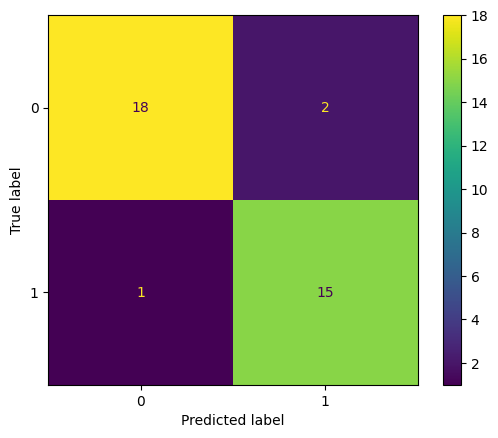

In [ ]:
#Mtriz de confusão plotada em Matplot lib
cm = confusion_matrix(y_test,predict_metrics)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()